In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
neevvv_tingkat_kemiskinan_di_negri_hytamputyh_path = kagglehub.dataset_download('neevvv/tingkat-kemiskinan-di-negri-hytamputyh')

print('Data source import complete.')


Using Colab cache for faster access to the 'tingkat-kemiskinan-di-negri-hytamputyh' dataset.
Data source import complete.


In [2]:
import pandas as pd
import numpy as np

df= pd.read_csv('/kaggle/input/tingkat-kemiskinan-di-negri-hytamputyh/dataset_tingkat_kemiskinan_hytamputyh.csv')
df

,ID,Pendidikan,Status_Pekerjaan,Jumlah_Tanggungan,Wilayah,Kepemilikan_Rumah,Kendaraan,Gaji_per_Bulan,Pengeluaran_per_Bulan,Tingkat_Kemiskinan
0,311166,S1,Apoteker,5,Kota,Milik Sendiri,Mobil,37875818,29637280,Kaya
1,621690,SMP,Tukang Becak,1,Kota,Kontrak,Motor,1001451,1150412,Sangat Miskin
2,733749,SMP,Kasir,5,Kota,Milik Orang Tua,Motor,5262068,4909404,Rentan Miskin
3,475167,S1,Data Analyst,5,Desa,Milik Sendiri,Mobil,17225626,13198287,Menengah Atas
4,531612,S1,Guru,1,Kota,Milik Orang Tua,Motor,11065675,7382116,Menengah
...,...,...,...,...,...,...,...,...,...,...
4995,187129,SMA,Buruh Bangunan,5,Kota,Kontrak,Motor,3055583,3818494,Miskin
4996,414058,D3,PNS,0,Kota,Milik Orang Tua,Motor,14946707,9636020,Menengah Atas
4997,398595,SMA,Pedagang Kaki Lima,0,Kota,Milik Orang Tua,Motor,3317376,2601571,Miskin
4998,344968,S2,Konsultan,3,Desa,Milik Sendiri,Mobil,22168609,14831250,Kaya


In [3]:
df['Status_Pekerjaan'].value_counts(ascending= False)

,count
Status_Pekerjaan,
Pemulung,221
Pengangguran,216
Nelayan,214
Petani,210
Buruh Bangunan,205
Pedagang Kaki Lima,204
Tukang Becak,201
Buruh Harian Lepas,195
Kurir,182


# Categorical Value Simplification

In [4]:
job = {
    'Dokter Umum': 'Profesional', 'Arsitek': 'Profesional', 'Apoteker': 'Profesional',
    'Dosen': 'Profesional', 'Konsultan': 'Profesional', 'Manajer': 'Profesional',
    'Software Engineer': 'Profesional', 'Data Analyst': 'Profesional', 'Auditor': 'Profesional',

    'Akuntan': 'Staf', 'HRD': 'Staf', 'PNS': 'Staf', 'Admin': 'Staf',
    'Customer Service': 'Staf', 'Guru': 'Staf', 'Perawat': 'Staf',
    'Programmer Junior': 'Staf', 'Sales': 'Staf', 'Teknisi': 'Staf',

    'Buruh Bangunan': 'Informal', 'Buruh Pabrik': 'Informal', 'Kasir': 'Informal',
    'Kurir': 'Informal', 'Operator Produksi': 'Informal', 'Pedagang Kaki Lima': 'Informal',
    'Petani': 'Informal', 'Nelayan': 'Informal', 'Buruh Harian Lepas': 'Informal',
    'Tukang Becak': 'Informal', 'Pemulung': 'Informal',

    'Pengangguran': 'Pengangguran'
}

In [5]:
df['Pekerjaan'] = df['Status_Pekerjaan'].map(job)
df[['Status_Pekerjaan', 'Pekerjaan']].head(10)

,Status_Pekerjaan,Pekerjaan
0,Apoteker,Profesional
1,Tukang Becak,Informal
2,Kasir,Informal
3,Data Analyst,Profesional
4,Guru,Staf
5,Customer Service,Staf
6,Programmer Junior,Staf
7,Admin,Staf
8,Buruh Harian Lepas,Informal
9,Pengangguran,Pengangguran


# Entropy + Gain Value

In [6]:
import numpy as np

def entropy(df, target):
  elemen, jumlah = np.unique(df[target], return_counts=True)
  entropy = 0
  for i in range(len(elemen)):
    entropy += -(jumlah[i]/np.sum(jumlah) * np.log2(jumlah[i]/np.sum(jumlah)))
  return entropy

def gain(df, atribut, target="Tingkat_Kemiskinan"):
  elemen, jumlah = np.unique(df[atribut], return_counts=True)
  gain_sigmoid = 0

  for i in range(len(elemen)):
    gain_sigmoid += (jumlah[i]/len(df)) * entropy(df[df[atribut] == elemen[i]], target)
  return entropy(df, target) - gain_sigmoid

# Tree Loop

In [7]:
def tree_loop(df, target, daftar_fitur):
    if len(np.unique(df[target])) <= 1:
        return np.unique(df[target])[0]

    if len(daftar_fitur) == 0:
        elemen, jumlah = np.unique(df[target], return_counts=True)
        return elemen[np.argmax(jumlah)]
    nilai_gain = [gain(df, fitur, target) for fitur in daftar_fitur]
    index_terbaik = np.argmax(nilai_gain)
    fitur_terbaik = daftar_fitur[index_terbaik]
    tree = {fitur_terbaik: {}}
    sisa_fitur = [f for f in daftar_fitur if f != fitur_terbaik]

    for nilai in np.unique(df[fitur_terbaik]):
        sub_df = df[df[fitur_terbaik] == nilai].copy()
        tree[fitur_terbaik][nilai] = tree_loop(sub_df, target, sisa_fitur)

    return tree

In [8]:
import pprint

fitur_pilihan = [
    'Pendidikan',
    'Pekerjaan',
    'Kepemilikan_Rumah',
    'Wilayah',
    'Kendaraan',
    # 'Kategori_Gaji'
]

target = 'Tingkat_Kemiskinan'

tree_target_pred = tree_loop(df, target, fitur_pilihan)
pprint.pprint(tree_target_pred)

{'Pendidikan': {'D3': {'Pekerjaan': {'Profesional': 'Menengah Atas',
                                     'Staf': {'Kendaraan': {'Mobil': {'Kepemilikan_Rumah': {'Milik Orang Tua': {'Wilayah': {'Desa': 'Menengah',
                                                                                                                            'Kota': 'Menengah'}},
                                                                                            'Milik Sendiri': {'Wilayah': {'Desa': 'Menengah '
                                                                                                                                  'Atas',
                                                                                                                          'Kota': 'Menengah '
                                                                                                                                  'Atas'}}}},
                                                            'Motor': {'Kepemi

# Prediction

In [9]:
def predict(tree, new_data):
    if type(tree) is not dict:
        return tree

    fitur_now = list(tree.keys())[0]
    jawaban_hytam = new_data.get(fitur_now)

    next_branch = tree[fitur_now].get(jawaban_hytam)
    if next_branch is None:
        pilihan_darurat = list(tree[fitur_now].keys())[0]
        print(f"Probabilitas dari '{jawaban_hytam}' di fitur [{fitur_now}] tidak ada ya hytam")
        print(f"'{pilihan_darurat}'\n\n")

        next_branch = tree[fitur_now][pilihan_darurat]

    return predict(next_branch, new_data)

# Model Evaluation

In [10]:
people = {
    'Pendidikan': 'SMP',
    'Pekerjaan': 'Informal',
    'Kepemilikan_Rumah': 'Kontrak',
    'Wilayah': 'Kota',
    'Kendaraan': 'Motor'
}

pred = predict(tree_target_pred, people)
print(f'prediksi kekayaan : {pred}')

prediksi kekayaan : Rentan Miskin


In [11]:
# Accuracy
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

selected_features = ['Pendidikan', 'Pekerjaan', 'Kepemilikan_Rumah', 'Wilayah', 'Kendaraan']
target = 'Tingkat_Kemiskinan'

print("Training the model, please wait...")
decision_tree = tree_loop(train_data, target, selected_features)
print("Training completed! Starting evaluation...\n")

correct_predictions = 0
total_samples = len(test_data)

for index, row in test_data.iterrows():
    person_data = row.to_dict()

    predicted_result = predict(decision_tree, person_data)

    actual_result = person_data[target]

    if predicted_result == actual_result:
        correct_predictions += 1

accuracy = (correct_predictions / total_samples) * 100

print(f"--- MODEL EVALUATION RESULT ---")
print(f"Total test samples    : {total_samples}")
print(f"Correct predictions   : {correct_predictions}")
print(f"Accuracy              : {accuracy:.2f}%")

Training the model, please wait...
Training completed! Starting evaluation...

--- MODEL EVALUATION RESULT ---
Total test samples    : 1000
Correct predictions   : 763
Accuracy              : 76.30%


Calculating the learning curve, please wait...
Probabilitas dari 'Milik Orang Tua' di fitur [Kepemilikan_Rumah] tidak ada ya hytam
'Milik Sendiri'


Probabilitas dari 'Milik Orang Tua' di fitur [Kepemilikan_Rumah] tidak ada ya hytam
'Milik Sendiri'


Probabilitas dari 'Milik Orang Tua' di fitur [Kepemilikan_Rumah] tidak ada ya hytam
'Milik Sendiri'


Probabilitas dari 'Milik Orang Tua' di fitur [Kepemilikan_Rumah] tidak ada ya hytam
'Milik Sendiri'


Probabilitas dari 'Sepeda' di fitur [Kendaraan] tidak ada ya hytam
'Mobil'


Probabilitas dari 'Milik Sendiri' di fitur [Kepemilikan_Rumah] tidak ada ya hytam
'Kontrak'


Probabilitas dari 'Desa' di fitur [Wilayah] tidak ada ya hytam
'Kota'


Probabilitas dari 'Mobil' di fitur [Kendaraan] tidak ada ya hytam
'Motor'


Probabilitas dari 'Desa' di fitur [Wilayah] tidak ada ya hytam
'Kota'


Probabilitas dari 'Tidak Ada' di fitur [Kendaraan] tidak ada ya hytam
'Motor'


Probabilitas dari 'Desa' di fitur [Wilayah] tidak ada ya hytam
'Kota'


Pr

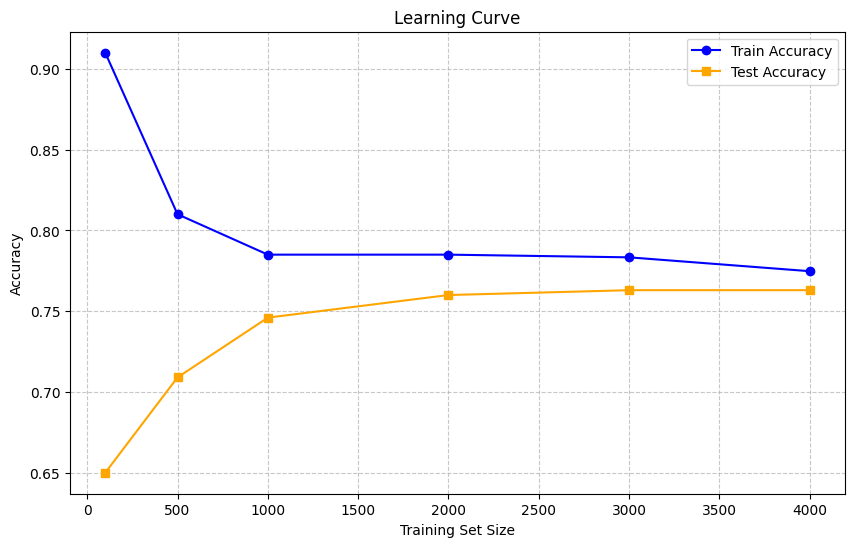

In [12]:
# Learning Curve
import matplotlib.pyplot as plt

def calculate_accuracy(tree, test_data, target_name):
    correct_predictions = 0

    for index, row in test_data.iterrows():
        data_dict = row.to_dict()

        predicted_result = predict(tree, data_dict)

        if predicted_result == data_dict[target_name]:
            correct_predictions += 1

    return correct_predictions / len(test_data)

training_sizes = [100, 500, 1000, 2000, 3000, len(train_data)]

train_accuracies = []
test_accuracies = []

print("Calculating the learning curve, please wait...")

for size in training_sizes:
    training_subset = train_data.iloc[:size]

    current_tree = tree_loop(training_subset, target, selected_features)

    train_accuracy = calculate_accuracy(current_tree, training_subset, target)
    train_accuracies.append(train_accuracy)

    test_accuracy = calculate_accuracy(current_tree, test_data, target)
    test_accuracies.append(test_accuracy)

print("Completed! Displaying the graph...")

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, train_accuracies, marker='o', color='blue', label='Train Accuracy')
plt.plot(training_sizes, test_accuracies, marker='s', color='orange', label='Test Accuracy')

plt.title('Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()